# 01 - Data acquisition & EDA
UCI Heart Disease (Cleveland subset, 303 patients, 13 features + diagnosis).
The raw `num` column (0-4) is collapsed to a binary `target`: 0 = no disease, 1 = any disease.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from heart import data, eda
from heart.config import NUMERIC, CATEGORICAL, BINARY, TARGET
%matplotlib inline

## 1. Acquire
`python -m heart.data` downloads `processed.cleveland.data` from UCI (cached in `data/raw/`).

In [3]:
raw = data.load_raw(data.download_raw())
print(raw.shape)
raw.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data quality
Missing values are encoded as `?` in the raw file; they only occur in `ca` and `thal`.

In [4]:
raw.isna().sum().to_frame('missing').T

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
missing,0,0,0,0,0,0,0,0,0,0,0,4,2,0


In [5]:
raw.dtypes.to_frame('dtype').T

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


## 3. Clean
`heart.data.clean` coerces types, binarises the target and drops exact duplicates. Missing `ca`/`thal` are **not** imputed here - imputation is learned inside the model pipeline on training folds only, so no test information leaks into the fill values.

In [6]:
df = data.clean(raw)
df.to_csv(data.CLEAN_PATH, index=False)
print(df.shape)
df.describe().T.round(2)

(303, 14)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


## 4. Class balance

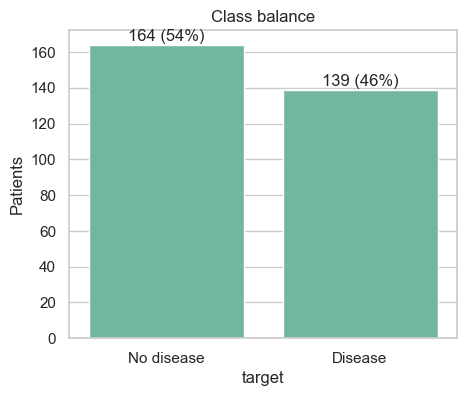

In [7]:
eda.plot_class_balance(df); plt.show()

164 vs 139 (54% / 46%) - mildly imbalanced, so accuracy alone is acceptable but we also track precision, recall and ROC-AUC, and try `class_weight='balanced'` during tuning.

## 5. Numeric distributions

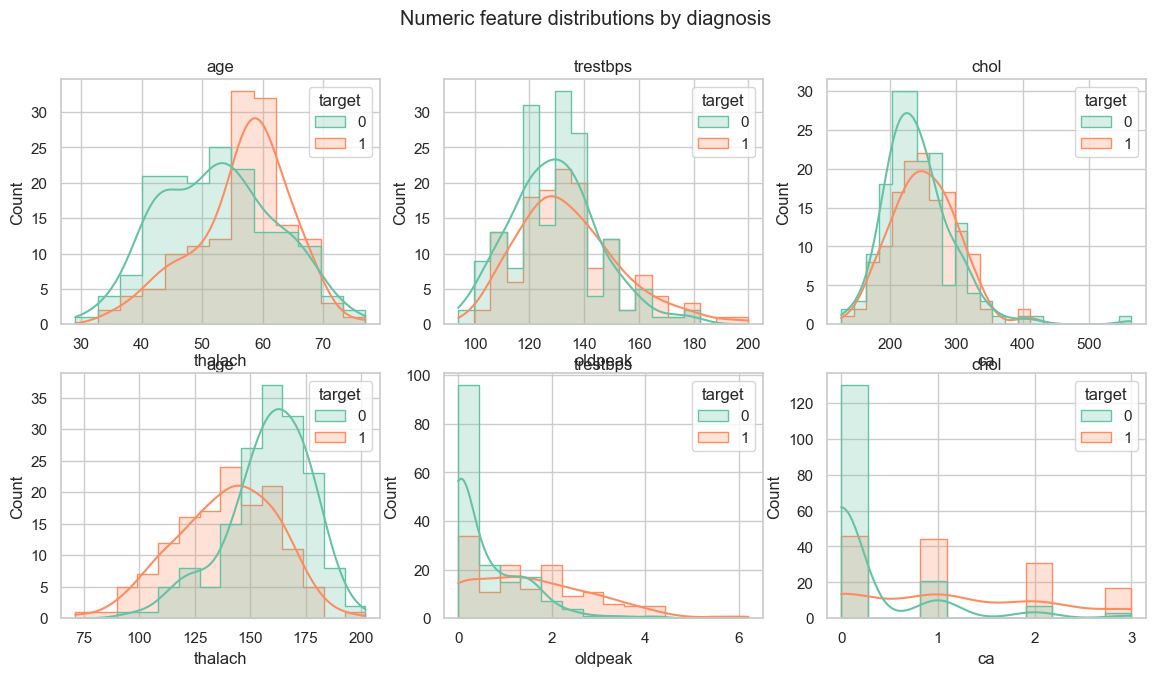

In [8]:
eda.plot_numeric_histograms(df); plt.show()

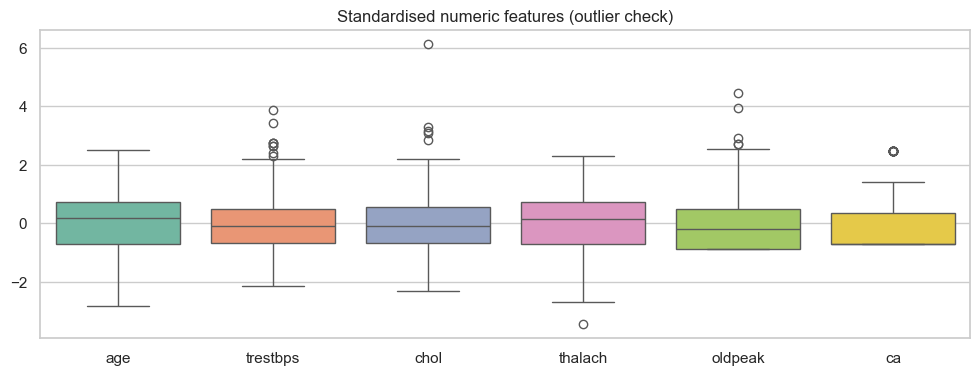

In [9]:
eda.plot_outliers(df); plt.show()

Patients with disease reach a lower max heart rate (`thalach`) and show more ST depression (`oldpeak`). `chol` has a long right tail (max 564) - kept, since it is physiologically plausible and scaling handles it.

## 6. Categorical features vs disease rate

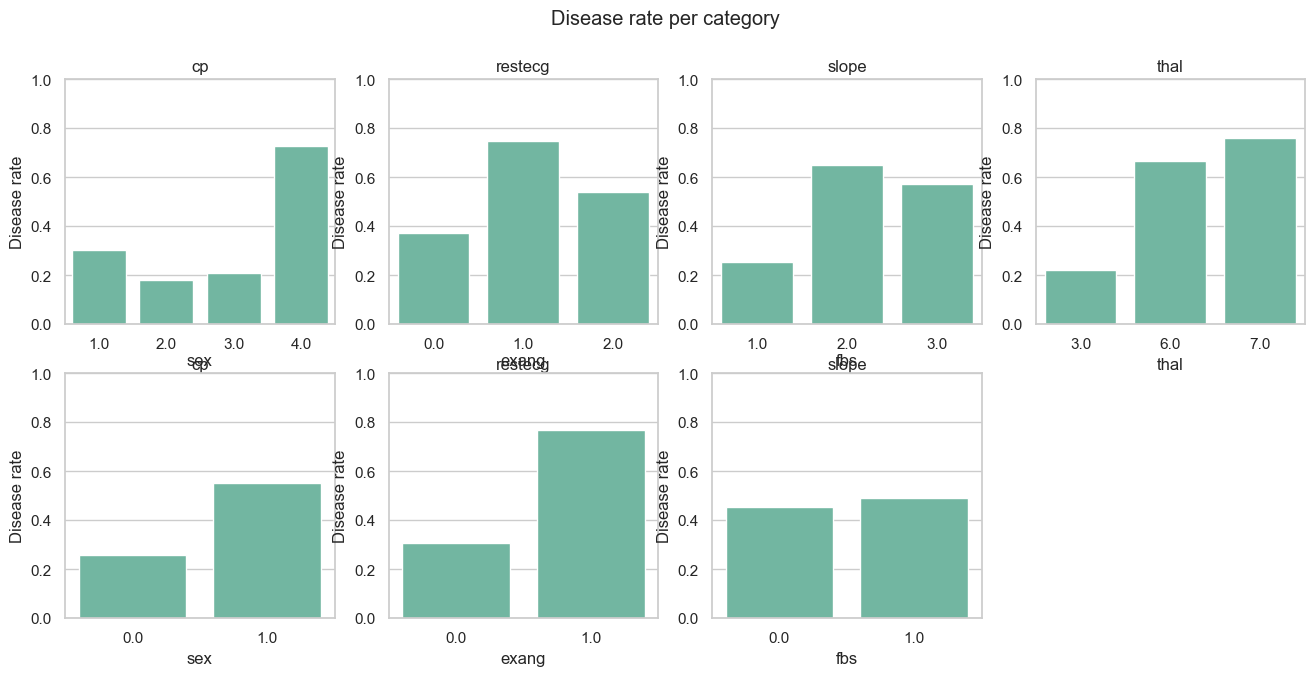

In [10]:
eda.plot_categorical_rates(df); plt.show()

In [11]:
for c in CATEGORICAL + BINARY + ['ca']:
    print(c, df.groupby(c)[TARGET].mean().round(2).to_dict())

cp {1.0: 0.3, 2.0: 0.18, 3.0: 0.21, 4.0: 0.73}
restecg {0.0: 0.37, 1.0: 0.75, 2.0: 0.54}
slope {1.0: 0.25, 2.0: 0.65, 3.0: 0.57}
thal {3.0: 0.22, 6.0: 0.67, 7.0: 0.76}
sex {0.0: 0.26, 1.0: 0.55}
fbs {0.0: 0.45, 1.0: 0.49}
exang {0.0: 0.31, 1.0: 0.77}
ca {0.0: 0.26, 1.0: 0.68, 2.0: 0.82, 3.0: 0.85}


Asymptomatic chest pain (`cp=4`) carries a 73% disease rate versus ~20% for the other types; reversible thal defect (`thal=7`) 76%; exercise angina 77%. These are nominal codes, so they are one-hot encoded.

## 7. Correlation

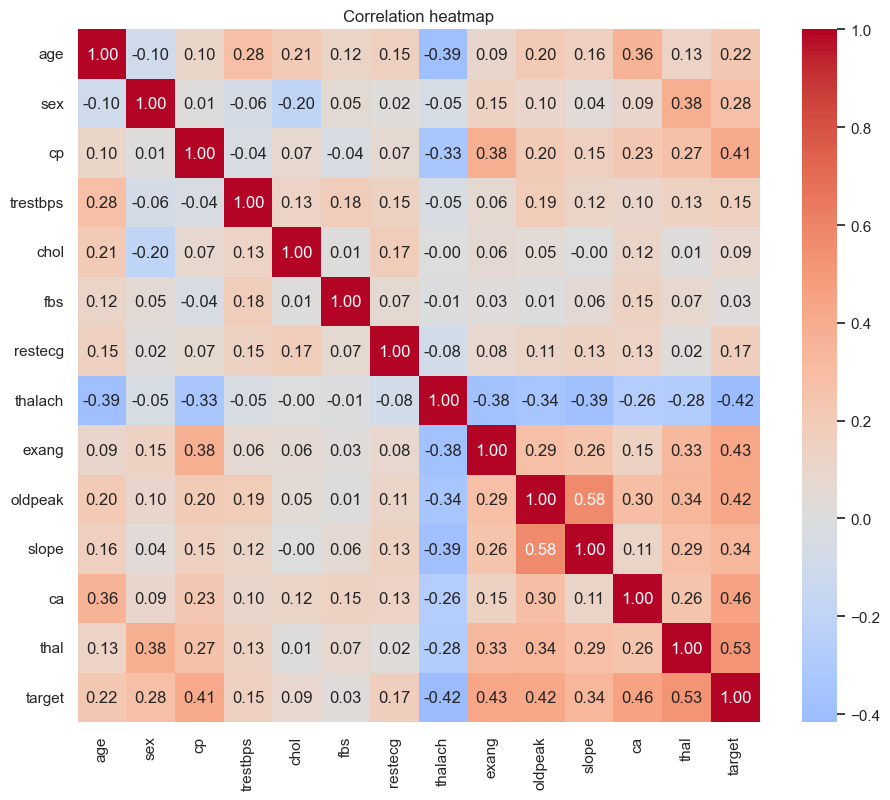

In [12]:
eda.plot_correlation(df); plt.show()

In [13]:
df.corr()[TARGET].drop(TARGET).sort_values().round(3)

thalach    -0.417
fbs         0.025
chol        0.085
trestbps    0.151
restecg     0.169
age         0.223
sex         0.277
slope       0.339
cp          0.414
oldpeak     0.425
exang       0.432
ca          0.460
thal        0.526
Name: target, dtype: float64

## 8. Takeaways for modelling
- Strongest signals: `thal`, `ca`, `exang`, `oldpeak`, `cp` (positive) and `thalach` (negative).
- `fbs` and `chol` are weak on their own - kept, the models decide.
- Nominal codes (`cp`, `restecg`, `slope`, `thal`) -> one-hot; continuous -> median impute + standard scale.
- Derived features: `hr_reserve = thalach / (220 - age)` (share of age-predicted max heart rate reached) and `chol_per_age`.

In [14]:
eda.run_eda()

Saved 5 figures to /Users/kmunot/Personal/BITS-Assignments/MLOPS/reports/figures
